Loading the data processed by hdWGCNA in R

In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isoctx-CTX-Glut"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / "AnnData/" / f"WMB-10Xv3-{select_region}-raw-wmeta-filtered.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 44121 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Loading Module Eigengenes dataframe
select_region = "CTX-Glut"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Super-M1,kME_grey,kME_Super-M2,kME_Super-M3,kME_Super-M4,kME_Super-M5
ENSMUSG00000047907,ENSMUSG00000047907,Super-M1,blue,0.169341,-0.027744,0.007262,-0.017396,0.092492,0.080882
ENSMUSG00000043659,ENSMUSG00000043659,grey,grey,0.015921,0.024608,0.079933,-0.034351,-0.042799,-0.021070
ENSMUSG00000111765,ENSMUSG00000111765,grey,grey,-0.012542,0.010194,0.021772,-0.006643,-0.017006,0.009608
ENSMUSG00000112375,ENSMUSG00000112375,Super-M2,turquoise,0.018164,0.106982,0.150459,0.026951,-0.108488,-0.092622
ENSMUSG00000062209,ENSMUSG00000062209,Super-M2,turquoise,-0.140888,-0.084647,0.217955,0.111928,-0.121177,-0.030553


In [5]:
modules_df = modules_df[modules_df["module"] != "grey"].copy()

In [8]:
# module_names = {
#     "Isocortex-M1": "Oligodendrocyte Myelination",
#     "Isocortex-M2": "Neuronal Projection",
#     "Isocortex-M3": "Immune Response",
#     "Isocortex-M4": "Vascular Morphogenesis",
#     "Isocortex-M5": "Developmental Signaling",
#     "Isocortex-M6": "Neural Development",
#     "Isocortex-M7": "Structural Morphogenesis",
#     "Isocortex-M8": "Extracellular Matrix",
#     "Isocortex-M9": "Axon Guidance",
# }

In [9]:
# # Rename the 'module' column in modules_df using module_names and save as a new dataframe
# modules_df_renamed = modules_df.copy()
# modules_df_renamed["module"] = modules_df_renamed["module"].map(module_names).fillna(modules_df_renamed["module"])
# modules_df_renamed.head()

## GO

In [6]:
from gprofiler import GProfiler

module_gene_dict = modules_df.groupby("module")["gene_name"].apply(list).to_dict()

gp = GProfiler(return_dataframe=True)
all_results = []

for module, genes in module_gene_dict.items():
    # gProfiler expects gene symbols or ENSEMBL IDs
    if len(genes) == 0:
        continue
    res = gp.profile(
        organism="mmusculus",
        query=genes,
        sources=['GO:BP'],
        user_threshold=0.05,
        significance_threshold_method='fdr'
    )
    if res.empty:
        continue
    res['module'] = module
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)

In [ ]:
# results_df.to_csv("outputs/glut_modules_go.csv")

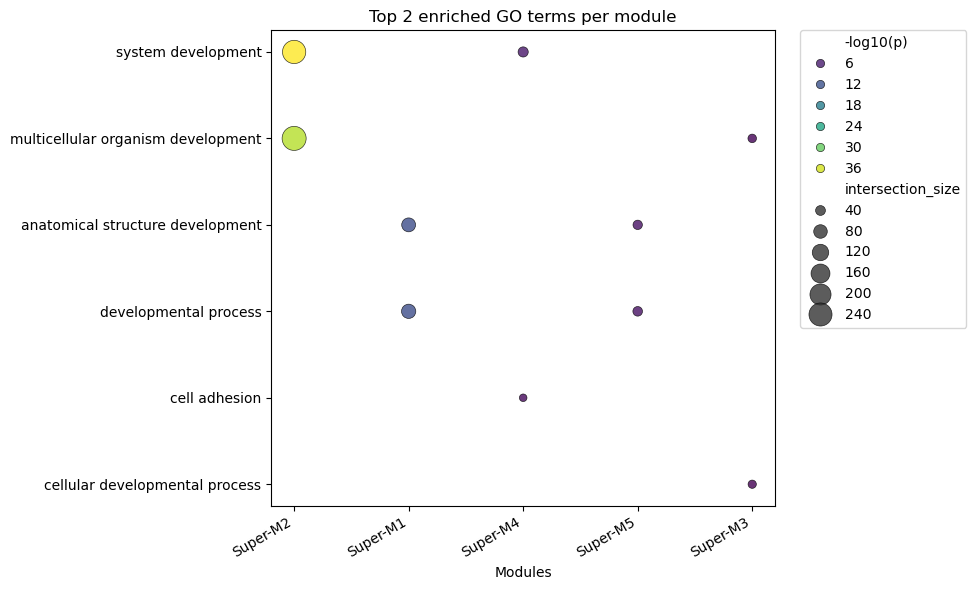

In [8]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    results_df
    .sort_values("p_value")
    .groupby("module")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="module",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=30, ha="right")
plt.ylabel("")
plt.xlabel("Modules")
plt.title(f"Top {top_n} enriched GO terms per module")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.savefig("figures/go_Super_CNA.svg")
plt.show()

## ME

In [6]:
from sklearn.decomposition import PCA

# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.scale(adata)  # Scale the data

# Get unique modules and their gene lists
module_gene_dict = modules_df.groupby("module")["gene_name"].apply(list).to_dict()

# Store eigengenes in a DataFrame
eigengenes = pd.DataFrame(index=adata.obs_names)

for module, genes in module_gene_dict.items():
    # Filter genes present in adata
    genes_in_adata = [g for g in genes if g in adata.var_names]
    if len(genes_in_adata) < 2:
        continue  # Need at least 2 genes for PCA

    # Extract expression matrix for the module
    X = adata[:, genes_in_adata].X
    if not isinstance(X, np.ndarray):
        X = X.toarray()  # Convert sparse to dense if needed

    # Compute first principal component (eigengene)
    pca = PCA(n_components=1)
    eigengene = pca.fit_transform(X).flatten()
    eigengenes[module] = eigengene

eigengenes.head()

,Super-M1,Super-M2,Super-M3,Super-M4,Super-M5
cell_label,,,,,
ACTATCTGTGTCTTCC-352_A04,2.092940,-0.096631,1.973607,3.508925,2.274204
GTTCTATTCTCCCATG-393_D05,0.772838,-2.337074,2.253582,4.773571,2.239273
AAGCATCGTCCGACGT-390_B02,0.709101,1.630964,-1.392689,-1.309827,1.726011
ACAACCAGTGCCCGTA-1219_A01,-2.219059,11.159331,-1.471428,-1.673512,3.269773
ATCTTCACATTCGATG-390_B02,1.378878,9.460931,-2.835556,-2.536451,3.459789


In [ ]:
# custom_module_order = [
#  'Axon Guidance',
#  'Neuronal Projection',
#  'Developmental Signaling',
#  'Neural Development',
#  'Oligodendrocyte Myelination',
#  'Extracellular Matrix',
#  'Structural Morphogenesis',
#  'Vascular Morphogenesis',
#  'Immune Response'
#  ]

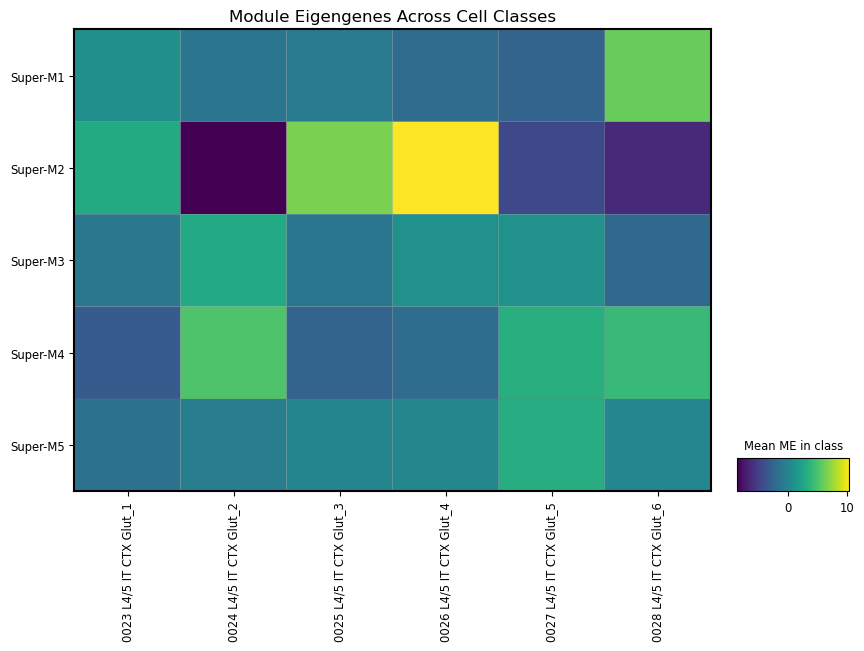

In [7]:
# Convert to AnnData (required for scanpy plotting)
adata_vis = sc.AnnData(eigengenes)
adata_vis.obs["supertype"] = adata.obs["supertype"]  # Add cell type labels

# Matrixplot
sc.pl.matrixplot(
    adata_vis,
    var_names=eigengenes.columns, # eigengenes.columns, custom_module_order
    groupby="supertype",
    swap_axes=True,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Classes",
    colorbar_title="Mean ME in class",
    cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    use_raw=False,
)

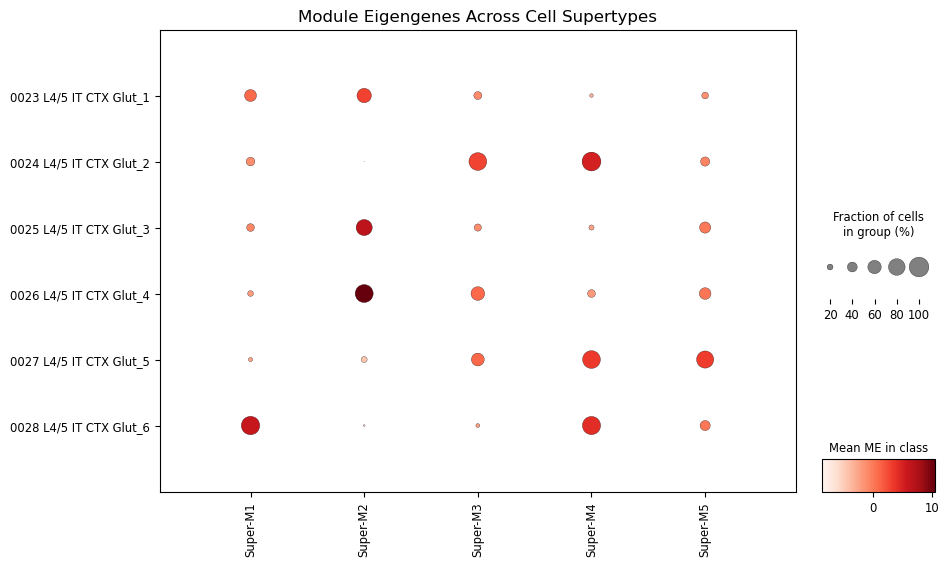

In [8]:
# Matrixplot
sc.pl.dotplot(
    adata_vis,
    var_names=eigengenes.columns,
    groupby="supertype",
    swap_axes=False,  # Show modules on y-axis, cell types on x-axis
    figsize=(10, 6),  # Adjust size as needed
    title="Module Eigengenes Across Cell Supertypes",
    colorbar_title="Mean ME in class",
    # cmap="viridis",  # Color map
    dendrogram=False,  # Disable clustering for simplicity
    save = "Super_CNA.svg",
    use_raw=False,
)

In [16]:
# Adding MEs to AnnData object
merged_df = pd.merge(adata.obs, eigengenes, left_index=True, right_index=True)
merged_df.head()

,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,...,subclass_color,supertype_color,cluster_color,region_of_interest_order,region_of_interest_color,Super-M1,Super-M2,Super-M3,Super-M4,Super-M5
cell_label,,,,,,,,,,,,,,,,,,,,,
ACTATCTGTGTCTTCC-352_A04,ACTATCTGTGTCTTCC,352_A04,L8TX_200903_01_F11,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-540566,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#3DCCB7,#0F6619,#543D66,8,#00990A,2.092940,-0.096631,1.973607,3.508925,2.274204
GTTCTATTCTCCCATG-393_D05,GTTCTATTCTCCCATG,393_D05,L8TX_201016_01_G04,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,ACA,Snap25-IRES2-Cre;Ai14-546812,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#3DCCB7,#4DFFA3,#996F45,8,#00990A,0.772838,-2.337074,2.253582,4.773571,2.239273
AAGCATCGTCCGACGT-390_B02,AAGCATCGTCCGACGT,390_B02,L8TX_201015_01_H02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,PL-ILA-ORB,Snap25-IRES2-Cre;Ai14-546799,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#3DCCB7,#639917,#661B0F,9,#8CCC00,0.709101,1.630964,-1.392689,-1.309827,1.726011
ACAACCAGTGCCCGTA-1219_A01,ACAACCAGTGCCCGTA,1219_A01,L8TX_220421_01_G07,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,PL-ILA-ORB,Snap25-IRES2-Cre;Ai14-621471,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#3DCCB7,#0F6619,#1FBBCC,9,#8CCC00,-2.219059,11.159331,-1.471428,-1.673512,3.269773
ATCTTCACATTCGATG-390_B02,ATCTTCACATTCGATG,390_B02,L8TX_201015_01_H02,WMB-10Xv3-Isocortex-1,cell,NaN,10Xv3,PL-ILA-ORB,Snap25-IRES2-Cre;Ai14-546799,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,...,#3DCCB7,#0F6619,#99FFCA,9,#8CCC00,1.378878,9.460931,-2.835556,-2.536451,3.459789


In [17]:
def plot_multiple_umaps(data, modules, x_col="x", y_col="y", fig_width=4, fig_height=4, cmap="viridis"):
    """
    Plots multiple UMAP visualizations for the specified modules.

    Parameters:
        data (pd.DataFrame): The dataframe containing UMAP coordinates and the module eigengenes.
        modules (list): List of module names to plot.
        x_col (str): Column name for the x-axis UMAP coordinate.
        y_col (str): Column name for the y-axis UMAP coordinate.
        fig_width (float): Width of each subplot.
        fig_height (float): Height of each subplot.
        cmap (str): Colormap for the scatter plots.

    Returns:
        None
    """
    n_cols = 4  # Number of columns for subplots
    n_rows = math.ceil(len(modules) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width * n_cols, fig_height * n_rows))
    axes = axes.flatten()

    for i, module in enumerate(modules):
        ax = axes[i]
        scatter = ax.scatter(
            data[x_col],
            data[y_col],
            s=0.5,
            c=data[module],
            cmap=cmap,
            marker='.',
            edgecolor='none'
        )

        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(module)

        fig.colorbar(scatter, ax=ax, orientation='vertical', label=module)

    # Turn off unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

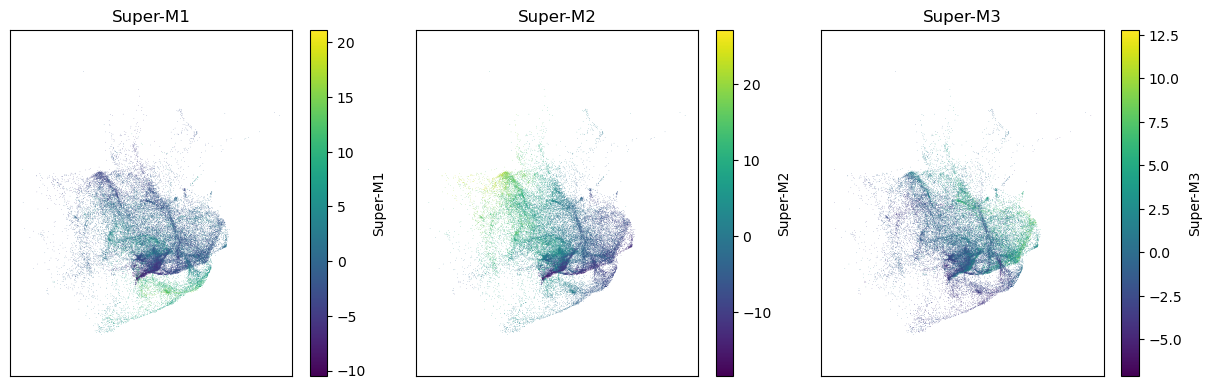

In [18]:
select_modules = ["Super-M1", "Super-M2", "Super-M3"]
plot_multiple_umaps(merged_df, select_modules)

In [14]:
tau_scores = {}

for module in select_modules:
    tau_df = merged_df[["supertype", module]].copy()
    tau_df[module] = tau_df[module] - tau_df[module].min() + 1e-6  # Shift the eigengene values to ensure non-negativity

    # Compute average eigengene per cell class
    avg_expression = tau_df.groupby('supertype', observed=False)[module].mean()

    # Normalize by the maximum average expression
    max_expr = avg_expression.max()
    normalized_expr = avg_expression / max_expr

    # Compute tau score
    tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
    tau_scores[module] = tau

# Print Tau scores for all modules
for module, score in tau_scores.items():
    print(f"Tau specificity score for {module} module: {score:.3f}")

Tau specificity score for Super-M1 module: 0.429
Tau specificity score for Super-M2 module: 0.430
Tau specificity score for Super-M3 module: 0.335
Tau specificity score for Super-M4 module: 0.364
Tau specificity score for Super-M5 module: 0.398


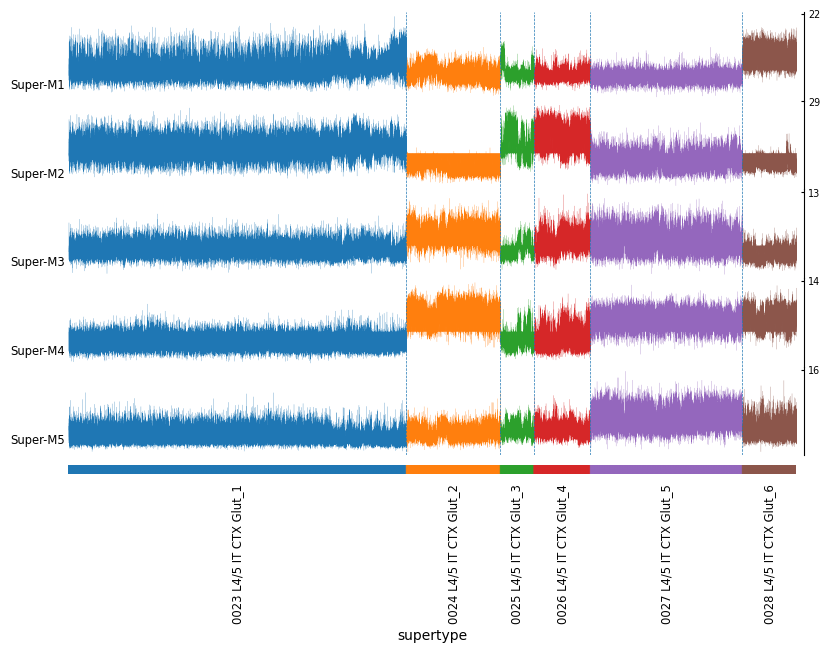

In [19]:
# Add all module eigengenes to AnnData and class labels
all_modules = [col for col in merged_df.columns if col in module_gene_dict.keys()]
adata_tracks = sc.AnnData(merged_df[all_modules])
adata_tracks.obs["supertype"] = merged_df["supertype"].astype("category")  # Ensure categorical dtype

# Plot tracksplot of module eigengenes across cell classes
sc.pl.tracksplot(
    adata_tracks,
    var_names=all_modules,
    groupby="supertype",
    figsize=(10, 6),
    dendrogram=False,
    title="Tracksplot of Module Eigengenes Across Cell Classes",
    # cmap="viridis"
)

In [20]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Super-M1,kME_grey,kME_Super-M2,kME_Super-M3,kME_Super-M4,kME_Super-M5
0,ENSMUSG00000039137,Super-M1,blue,0.616152,0.473128,0.068002,-0.023098,-0.060200,-0.472953
1,ENSMUSG00000024238,Super-M1,blue,0.610471,0.225749,0.112941,-0.219122,-0.065406,-0.241645
2,ENSMUSG00000078816,Super-M2,turquoise,0.191094,0.241738,0.761634,-0.297051,-0.645933,-0.262362
3,ENSMUSG00000017466,Super-M2,turquoise,0.374020,0.505130,0.726617,-0.282410,-0.708860,-0.536627
4,ENSMUSG00000067028,Super-M3,green,-0.234652,0.104496,-0.023562,0.670917,0.225332,-0.126472


In [21]:
gene_names_df = adata.var.copy()

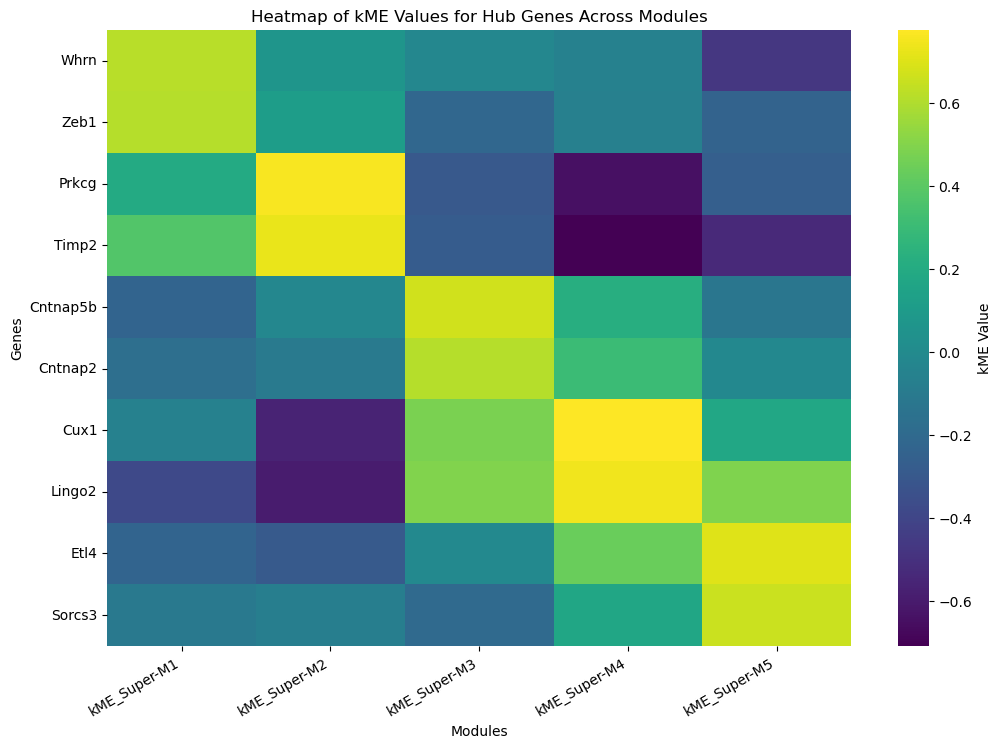

In [23]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
# heatmap_data.columns = [
#     module_names.get(col.replace("kME_", ""), col.replace("kME_", ""))
#     for col in heatmap_data.columns
# ]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xticks(rotation=30, ha="right")
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")
plt.savefig("figures/heatmap_kME_Super.svg")
plt.show()

### Overlap with DEGs

In [7]:
# Loading the DEG dataframe
group_by = "supertype"
select_region = "Isoctx-CTX-Glut"
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
deg_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results = pd.read_csv(deg_path)
deg_results.head(3)

,0023 L4/5 IT CTX Glut_1,0024 L4/5 IT CTX Glut_2,0025 L4/5 IT CTX Glut_3,0026 L4/5 IT CTX Glut_4,0027 L4/5 IT CTX Glut_5,0028 L4/5 IT CTX Glut_6
0,Galntl6,Cux1,Tox,Synpr,Lingo2,Tenm3
1,Slc24a3,Pld5,Pcp4,Syt17,Alcam,Tenm2
2,Pcp4,Atp1a1,Grik3,Atp2b4,Kctd1,Astn2


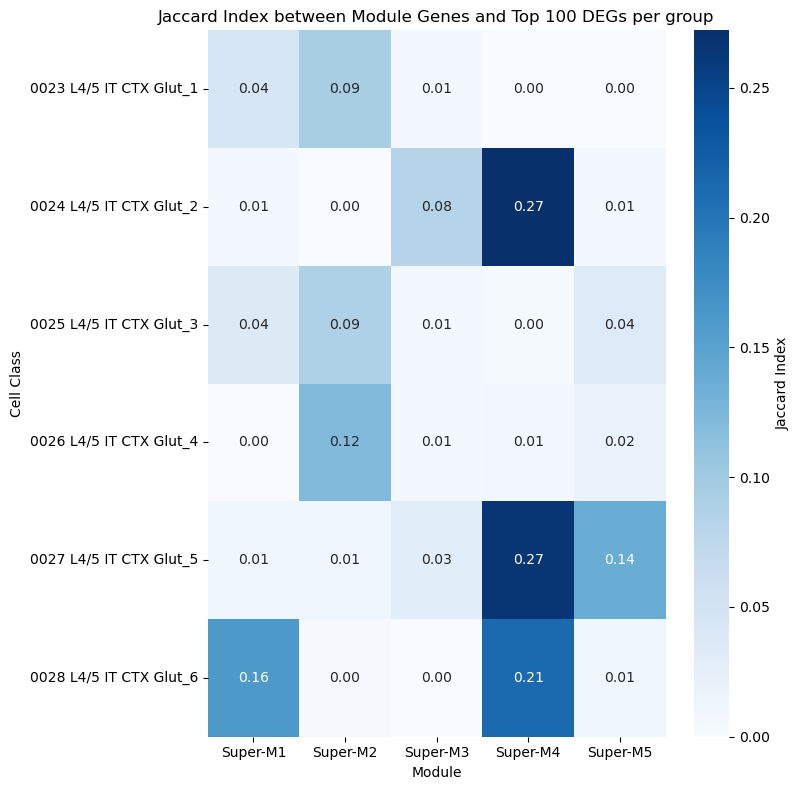

In [ ]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Jaccard index matrix
import pandas as pd
jaccard_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        intersection = len(mod_genes & deg_genes)
        union = len(mod_genes | deg_genes)
        jaccard = intersection / union if union > 0 else 0.0
        jaccard_matrix.loc[mod, cls] = jaccard

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    jaccard_matrix.astype(float).T,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Jaccard Index"}
)
plt.title("Jaccard Index between Module Genes and Top 100 DEGs per group")
plt.xlabel("Module")
plt.ylabel("Cell Class")
plt.tight_layout()
# plt.savefig("figures/heatmap_jaccard_index_Super_CNA.svg")
plt.show()

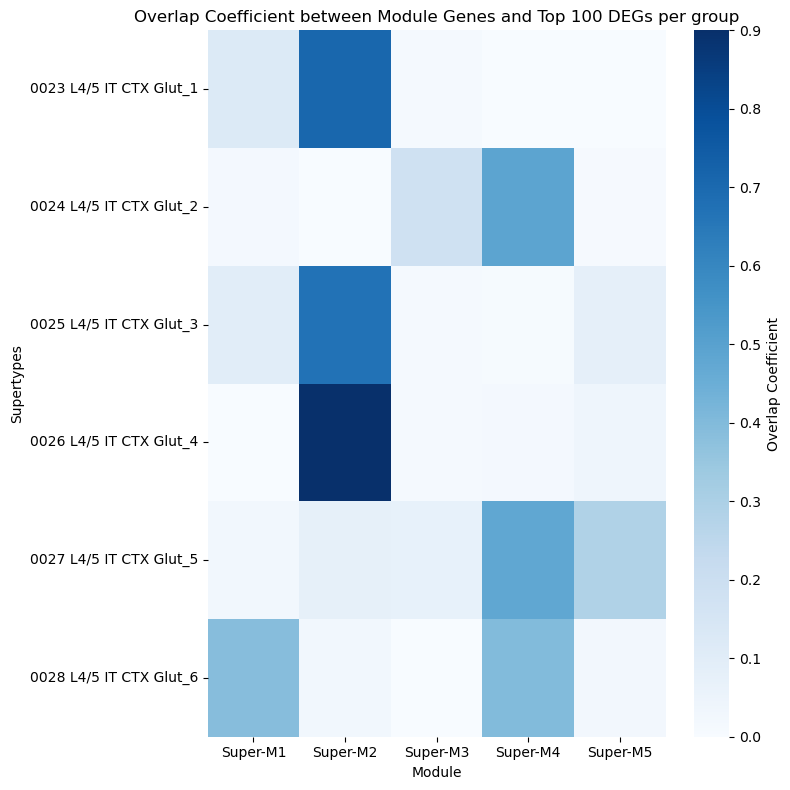

In [10]:
# 1. Get top 100 DEGs per class from deg_results (each column is a class, values are gene names)
top_n_deg = 100
deg_sets = {
    cls: set(deg_results[cls].dropna().head(top_n_deg))
    for cls in deg_results.columns
}

# 2. Build module gene sets (using gene symbols)
gene_symbol_map = adata.var["gene_symbol"].to_dict()
module_gene_sets = {
    mod: set([gene_symbol_map.get(g, g) for g in genes if gene_symbol_map.get(g, g) is not None])
    for mod, genes in module_gene_dict.items()
}

# 3. Compute Overlap Coefficient matrix (Szymkiewicz–Simpson)
import pandas as pd
import numpy as np

overlap_matrix = pd.DataFrame(
    index=module_gene_sets.keys(),
    columns=deg_sets.keys(),
    dtype=float
)

for mod, mod_genes in module_gene_sets.items():
    for cls, deg_genes in deg_sets.items():
        inter = len(mod_genes & deg_genes)
        denom = min(len(mod_genes), len(deg_genes))
        overlap = inter / denom if denom > 0 else np.nan  # avoid divide-by-zero
        overlap_matrix.loc[mod, cls] = overlap

# 4. Plot heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(
    overlap_matrix.astype(float).T,
    annot=False,
    fmt=".2f",
    cmap="Blues",
    cbar_kws={"label": "Overlap Coefficient"}
)
plt.title(f"Overlap Coefficient between Module Genes and Top {top_n_deg} DEGs per group")
plt.xlabel("Module")
plt.ylabel("Supertypes")
plt.tight_layout()
# plt.savefig("figures/heatmap_overlap_coefficient_Super_CNA.svg")
plt.show()
